# Fine-Tuning a Lightweight LLM for Intersection Safety Assessment Reporting

This notebook implements the full methodology for the project:

1. Generate a **synthetic instruction dataset** for intersection safety assessment reporting  
2. Split into **train / validation / test** sets  
3. Save data in **CSV, JSON, and Alpaca-style JSONL** formats  
4. Prepare **Unsloth + LoRA fine-tuning code**  
5. Run **base-model vs fine-tuned-model evaluation** using a rubric-based framework  

> Recommended environment for training: **Google Colab with GPU**

## 1) Install packages

Run this cell in a fresh environment.  
If you are using Colab for Unsloth training, you may need to restart the runtime after installation.

In [ ]:
# Run this in a fresh Colab / notebook environment
%pip install -q pandas numpy scikit-learn matplotlib tqdm
%pip install -q transformers datasets accelerate peft trl sentencepiece bitsandbytes
%pip install -q unsloth

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 630.8/630.8 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 17.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 961.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 120.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.4/418.4 kB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 100.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 120.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 2) Imports and configuration

In [ ]:
import os
import re
import json
import math
import random
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_NAME = "intersection_safety_llm"
OUTPUT_DIR = Path("./project_outputs")
DATA_DIR = OUTPUT_DIR / "data"
MODEL_DIR = OUTPUT_DIR / "models"
RESULTS_DIR = OUTPUT_DIR / "results"

for p in [OUTPUT_DIR, DATA_DIR, MODEL_DIR, RESULTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

NUM_SAMPLES = 300   # change anywhere from 200 to 500
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-9
print("Output folder:", OUTPUT_DIR.resolve())

Output folder: /content/project_outputs


## 3) Define the synthetic data schema

We create realistic intersection cases by varying:
- intersection geometry
- traffic control
- traffic volume
- speed limit
- pedestrian and bicycle facilities
- lighting
- visibility
- crash history
- roadside access and hazards
- observed operational/safety issues

Each generated sample will contain:
- **instruction**
- **input**
- **output**

In [ ]:
AREA_TYPES = ["Urban", "Suburban"]
INTERSECTION_TYPES = [
    "Four-leg signalized intersection",
    "Four-leg unsignalized intersection",
    "T-intersection",
    "Roundabout"
]
TRAFFIC_VOLUMES = ["Low", "Moderate", "High", "Very high"]
SPEED_LIMITS = [40, 50, 60, 70, 80]
LEFT_TURN_LANE = ["Present on all major approaches", "Missing on one major approach", "Missing on multiple approaches"]
RIGHT_TURN_SLIP = ["None", "Present on one approach", "Present on two approaches"]
PEDESTRIAN_FACILITIES = [
    "Marked crosswalks on all approaches",
    "Faded pedestrian crossings",
    "No dedicated pedestrian crossing on at least one approach",
    "Pedestrian refuge islands provided",
    "Signals present but push-buttons poorly placed"
]
BICYCLE_FACILITIES = [
    "No bicycle facility",
    "Shared lane markings present",
    "Bike lane terminates near intersection",
    "Continuous bike lane provided"
]
LIGHTING = ["Adequate", "Inadequate at night", "No dedicated street lighting"]
VISIBILITY = ["Good", "Moderate", "Restricted by parked vehicles", "Restricted by roadside objects"]
ROADSIDE_CONDITION = [
    "Commercial driveways near intersection",
    "Bus stop close to stop line",
    "Roadside fixed objects near corner clearance",
    "School activity nearby",
    "Open roadside with limited hazards"
]
SURFACE_CONDITION = ["Dry", "Wet during rain events", "Skid resistance concerns reported"]
SIGNAGE_MARKINGS = [
    "Good condition",
    "Faded lane markings",
    "Advance warning signs insufficient",
    "Stop bar visibility poor"
]
SIGNAL_OPERATION = [
    "Not applicable",
    "Normal operation",
    "Short amber and all-red clearance suspected",
    "Signal coordination causes queue spillback",
    "Pedestrian phase timing may be insufficient"
]
OBSERVED_CONFLICTS = [
    "Few visible conflicts",
    "Rear-end conflicts during peak hours",
    "Turning conflicts with pedestrians",
    "Angle conflicts from gap acceptance issues",
    "Speeding on major approach",
    "Queue spillback blocks intersection",
    "Near-miss events involving cyclists"
]
CRASH_HISTORY = [
    "No serious crash pattern reported",
    "Frequent rear-end crashes",
    "Frequent angle crashes",
    "Pedestrian near-miss incidents reported",
    "Nighttime crashes higher than expected",
    "Turning-related crashes observed",
    "Run-off-road incidents on approach"
]
HEAVY_VEHICLE_SHARE = ["Low", "Moderate", "High"]

## 4) Risk scoring and expert-style report generation

To avoid random low-quality targets, the notebook uses a simple engineering-style logic:
- risky conditions increase a **risk score**
- the score maps to **overall safety level**
- safety concerns and countermeasures are generated from the specific deficiencies

This gives you a consistent synthetic dataset suitable for fine-tuning.

In [ ]:
def weighted_choice(options):
    return random.choice(options)

def sample_case():
    case = {
        "intersection_type": weighted_choice(INTERSECTION_TYPES),
        "area_type": weighted_choice(AREA_TYPES),
        "traffic_volume": weighted_choice(TRAFFIC_VOLUMES),
        "speed_limit_kmh": weighted_choice(SPEED_LIMITS),
        "left_turn_lane": weighted_choice(LEFT_TURN_LANE),
        "right_turn_slip_lane": weighted_choice(RIGHT_TURN_SLIP),
        "pedestrian_facilities": weighted_choice(PEDESTRIAN_FACILITIES),
        "bicycle_facilities": weighted_choice(BICYCLE_FACILITIES),
        "lighting": weighted_choice(LIGHTING),
        "visibility": weighted_choice(VISIBILITY),
        "roadside_condition": weighted_choice(ROADSIDE_CONDITION),
        "surface_condition": weighted_choice(SURFACE_CONDITION),
        "signage_markings": weighted_choice(SIGNAGE_MARKINGS),
        "signal_operation": weighted_choice(SIGNAL_OPERATION),
        "observed_conflicts": weighted_choice(OBSERVED_CONFLICTS),
        "crash_history": weighted_choice(CRASH_HISTORY),
        "heavy_vehicle_share": weighted_choice(HEAVY_VEHICLE_SHARE),
    }
    return case

def compute_risk_score(case):
    score = 0

    if case["traffic_volume"] == "Moderate":
        score += 1
    elif case["traffic_volume"] == "High":
        score += 2
    elif case["traffic_volume"] == "Very high":
        score += 3

    if case["speed_limit_kmh"] >= 70:
        score += 2
    elif case["speed_limit_kmh"] >= 60:
        score += 1

    if "Missing on one" in case["left_turn_lane"]:
        score += 2
    elif "Missing on multiple" in case["left_turn_lane"]:
        score += 3

    if "No dedicated pedestrian crossing" in case["pedestrian_facilities"]:
        score += 3
    elif "Faded pedestrian crossings" in case["pedestrian_facilities"]:
        score += 2
    elif "poorly placed" in case["pedestrian_facilities"]:
        score += 1

    if case["bicycle_facilities"] == "Bike lane terminates near intersection":
        score += 2

    if case["lighting"] == "Inadequate at night":
        score += 2
    elif case["lighting"] == "No dedicated street lighting":
        score += 3

    if "Restricted" in case["visibility"]:
        score += 2

    if "Commercial driveways" in case["roadside_condition"]:
        score += 2
    elif "Bus stop" in case["roadside_condition"]:
        score += 1
    elif "fixed objects" in case["roadside_condition"]:
        score += 2
    elif "School activity" in case["roadside_condition"]:
        score += 2

    if case["surface_condition"] == "Wet during rain events":
        score += 1
    elif case["surface_condition"] == "Skid resistance concerns reported":
        score += 2

    if case["signage_markings"] == "Faded lane markings":
        score += 1
    elif case["signage_markings"] == "Advance warning signs insufficient":
        score += 2
    elif case["signage_markings"] == "Stop bar visibility poor":
        score += 1

    if case["signal_operation"] == "Short amber and all-red clearance suspected":
        score += 2
    elif case["signal_operation"] == "Signal coordination causes queue spillback":
        score += 2
    elif case["signal_operation"] == "Pedestrian phase timing may be insufficient":
        score += 2

    conflict_points = {
        "Few visible conflicts": 0,
        "Rear-end conflicts during peak hours": 2,
        "Turning conflicts with pedestrians": 3,
        "Angle conflicts from gap acceptance issues": 3,
        "Speeding on major approach": 2,
        "Queue spillback blocks intersection": 2,
        "Near-miss events involving cyclists": 2,
    }
    score += conflict_points[case["observed_conflicts"]]

    crash_points = {
        "No serious crash pattern reported": 0,
        "Frequent rear-end crashes": 2,
        "Frequent angle crashes": 3,
        "Pedestrian near-miss incidents reported": 2,
        "Nighttime crashes higher than expected": 2,
        "Turning-related crashes observed": 2,
        "Run-off-road incidents on approach": 2,
    }
    score += crash_points[case["crash_history"]]

    if case["heavy_vehicle_share"] == "Moderate":
        score += 1
    elif case["heavy_vehicle_share"] == "High":
        score += 2

    if case["intersection_type"] == "Roundabout":
        score -= 1

    return max(score, 0)

def risk_level(score):
    if score <= 4:
        return "Low"
    elif score <= 8:
        return "Moderate"
    elif score <= 13:
        return "Moderate to high"
    else:
        return "High"

def extract_concerns(case):
    concerns = []
    countermeasures = []

    if "Missing" in case["left_turn_lane"]:
        concerns.append("the absence of adequate left-turn storage may increase turning and rear-end conflicts")
        countermeasures.append("provide or extend dedicated left-turn lanes where feasible")

    if "No dedicated pedestrian crossing" in case["pedestrian_facilities"]:
        concerns.append("pedestrian crossing opportunities are insufficient on at least one approach")
        countermeasures.append("install marked pedestrian crossings and review pedestrian control treatments")
    elif "Faded pedestrian crossings" in case["pedestrian_facilities"]:
        concerns.append("pedestrian markings are not sufficiently visible")
        countermeasures.append("refresh pedestrian crossing markings and improve signing")
    elif "poorly placed" in case["pedestrian_facilities"]:
        concerns.append("pedestrian control hardware may be inconvenient and underused")
        countermeasures.append("relocate or improve pedestrian push-button accessibility and timing")

    if case["bicycle_facilities"] == "Bike lane terminates near intersection":
        concerns.append("bicycle guidance is discontinuous near the conflict zone")
        countermeasures.append("provide continuous bicycle guidance through the intersection area")

    if case["lighting"] != "Adequate":
        concerns.append("nighttime visibility may be compromised by inadequate illumination")
        countermeasures.append("upgrade street lighting at the intersection and approaches")

    if "Restricted" in case["visibility"]:
        concerns.append("sight distance limitations may reduce driver reaction time")
        countermeasures.append("remove or relocate visibility obstructions and review parking/loading controls")

    if "Commercial driveways" in case["roadside_condition"]:
        concerns.append("nearby access points increase conflict density")
        countermeasures.append("apply access management measures near the intersection")
    elif "Bus stop" in case["roadside_condition"]:
        concerns.append("the nearby bus stop may create stopping, crossing, and visibility conflicts")
        countermeasures.append("review bus stop placement and pedestrian channelization")
    elif "fixed objects" in case["roadside_condition"]:
        concerns.append("fixed objects near the corner may worsen crash consequences")
        countermeasures.append("improve roadside clear zone or apply shielding where appropriate")
    elif "School activity" in case["roadside_condition"]:
        concerns.append("school-related pedestrian activity increases exposure during peak periods")
        countermeasures.append("consider school-zone speed management and crossing supervision")

    if case["surface_condition"] == "Wet during rain events":
        concerns.append("wet-weather operation may increase stopping distance")
        countermeasures.append("review drainage and pavement friction performance")
    elif case["surface_condition"] == "Skid resistance concerns reported":
        concerns.append("reduced pavement friction may contribute to loss-of-control or stopping problems")
        countermeasures.append("assess skid resistance and consider pavement surface treatment")

    if case["signage_markings"] != "Good condition":
        concerns.append("traffic control markings and signs may not provide sufficient guidance")
        countermeasures.append("renew lane markings, stop bars, and advance signing as needed")

    if case["signal_operation"] == "Short amber and all-red clearance suspected":
        concerns.append("signal clearance intervals may be insufficient for safe stopping and intersection clearance")
        countermeasures.append("review and optimize amber and all-red intervals")
    elif case["signal_operation"] == "Signal coordination causes queue spillback":
        concerns.append("queue spillback may block intersection operations and increase rear-end risk")
        countermeasures.append("review signal coordination and storage length on critical approaches")
    elif case["signal_operation"] == "Pedestrian phase timing may be insufficient":
        concerns.append("pedestrian timing may not match actual crossing demand")
        countermeasures.append("review pedestrian phase timing and crossing distance")

    conflict_text = case["observed_conflicts"]
    if conflict_text == "Rear-end conflicts during peak hours":
        concerns.append("peak-period queuing appears to contribute to rear-end conflicts")
        countermeasures.append("review approach storage, progression, and demand management")
    elif conflict_text == "Turning conflicts with pedestrians":
        concerns.append("turning vehicles are interacting unsafely with pedestrians")
        countermeasures.append("consider turn control, visibility improvements, and pedestrian priority treatments")
    elif conflict_text == "Angle conflicts from gap acceptance issues":
        concerns.append("gap-acceptance decisions may be contributing to angle crash risk")
        countermeasures.append("review control type, channelization, and sight distance")
    elif conflict_text == "Speeding on major approach":
        concerns.append("approach speeds appear higher than desirable for the surrounding context")
        countermeasures.append("consider speed management and advance warning measures")
    elif conflict_text == "Queue spillback blocks intersection":
        concerns.append("blocked intersection conditions degrade both safety and efficiency")
        countermeasures.append("evaluate signal timing, storage, and intersection demand management")
    elif conflict_text == "Near-miss events involving cyclists":
        concerns.append("cyclists may not be adequately accommodated through the intersection")
        countermeasures.append("review bicycle conflict areas and crossing continuity")

    crash_text = case["crash_history"]
    if crash_text != "No serious crash pattern reported":
        concerns.append(f"the reported crash pattern ({crash_text.lower()}) suggests a recurring safety issue")
        if "rear-end" in crash_text.lower():
            countermeasures.append("investigate queue warning, signal timing, and approach visibility")
        elif "angle" in crash_text.lower():
            countermeasures.append("review intersection control and sight distance for angle-crash reduction")
        elif "nighttime" in crash_text.lower():
            countermeasures.append("prioritize nighttime conspicuity and lighting improvements")
        elif "turning" in crash_text.lower():
            countermeasures.append("review turn paths, lane assignment, and protected turning treatments")
        elif "run-off-road" in crash_text.lower():
            countermeasures.append("review approach alignment, delineation, and roadside protection")

    # Deduplicate while preserving order
    concerns = list(dict.fromkeys(concerns))
    countermeasures = list(dict.fromkeys(countermeasures))

    return concerns[:4], countermeasures[:4]

def generate_report(case):
    score = compute_risk_score(case)
    level = risk_level(score)
    concerns, countermeasures = extract_concerns(case)

    intro = (
        f"This {case['area_type'].lower()} {case['intersection_type'].lower()} presents a "
        f"{level.lower()} safety risk based on its geometric, operational, and roadside characteristics."
    )

    context = (
        f"The intersection operates under {case['traffic_volume'].lower()} traffic demand with a posted speed limit of "
        f"{case['speed_limit_kmh']} km/h."
    )

    concern_sentence = (
        "Key concerns include " + "; ".join(concerns[:-1]) + ("; and " + concerns[-1] if len(concerns) > 1 else concerns[0]) + "."
        if concerns else
        "No major recurring safety deficiency is immediately apparent from the provided conditions."
    )

    recommendation_sentence = (
        "Recommended countermeasures include " + ", ".join(countermeasures[:-1]) + (
            ", and " + countermeasures[-1] if len(countermeasures) > 1 else countermeasures[0]
        ) + "."
        if countermeasures else
        "Routine monitoring and maintenance are recommended to preserve current safety performance."
    )

    closing = (
        "A detailed field review and, where available, supporting crash data analysis should be used to confirm priorities."
    )

    report = " ".join([intro, context, concern_sentence, recommendation_sentence, closing])

    return {
        "risk_score": score,
        "risk_level": level,
        "report": report
    }

def format_input_text(case):
    ordered = [
        ("Intersection type", case["intersection_type"]),
        ("Area type", case["area_type"]),
        ("Traffic volume", case["traffic_volume"]),
        ("Speed limit", f"{case['speed_limit_kmh']} km/h"),
        ("Left-turn lane", case["left_turn_lane"]),
        ("Right-turn slip lane", case["right_turn_slip_lane"]),
        ("Pedestrian facilities", case["pedestrian_facilities"]),
        ("Bicycle facilities", case["bicycle_facilities"]),
        ("Lighting", case["lighting"]),
        ("Visibility", case["visibility"]),
        ("Roadside condition", case["roadside_condition"]),
        ("Surface condition", case["surface_condition"]),
        ("Signage and markings", case["signage_markings"]),
        ("Signal operation", case["signal_operation"]),
        ("Observed conflicts", case["observed_conflicts"]),
        ("Crash history", case["crash_history"]),
        ("Heavy vehicle share", case["heavy_vehicle_share"]),
    ]
    return "\n".join([f"{k}: {v}" for k, v in ordered])

INSTRUCTION_TEXT = "Generate a transportation safety assessment report for the following intersection conditions."

The core synthetic generator is ready.  
Next we create 300 cases and inspect a few examples.

In [ ]:
records = []

for i in range(NUM_SAMPLES):
    case = sample_case()
    generated = generate_report(case)

    record = {
        "id": i + 1,
        "instruction": INSTRUCTION_TEXT,
        "input": format_input_text(case),
        "output": generated["report"],
        "risk_score": generated["risk_score"],
        "risk_level": generated["risk_level"],
        **case
    }
    records.append(record)

df = pd.DataFrame(records)
print("Dataset shape:", df.shape)
df[["id", "risk_level", "intersection_type", "traffic_volume", "speed_limit_kmh"]].head()

Dataset shape: (300, 23)


,id,risk_level,intersection_type,traffic_volume,speed_limit_kmh
0,1,High,Four-leg signalized intersection,High,50
1,2,High,Four-leg signalized intersection,Very high,50
2,3,High,Four-leg signalized intersection,Low,60
3,4,High,T-intersection,Low,40
4,5,High,Four-leg unsignalized intersection,Low,80


In [ ]:
# Show one full sample
sample_row = df.sample(1, random_state=SEED).iloc[0]
print("Instruction:\n", sample_row["instruction"])
print("\nInput:\n", sample_row["input"])
print("\nOutput:\n", sample_row["output"])

Instruction:
 Generate a transportation safety assessment report for the following intersection conditions.

Input:
 Intersection type: Roundabout
Area type: Suburban
Traffic volume: Low
Speed limit: 50 km/h
Left-turn lane: Missing on multiple approaches
Right-turn slip lane: Present on one approach
Pedestrian facilities: Marked crosswalks on all approaches
Bicycle facilities: No bicycle facility
Lighting: Adequate
Visibility: Restricted by roadside objects
Roadside condition: Roadside fixed objects near corner clearance
Surface condition: Wet during rain events
Signage and markings: Good condition
Signal operation: Pedestrian phase timing may be insufficient
Observed conflicts: Few visible conflicts
Crash history: Nighttime crashes higher than expected
Heavy vehicle share: Low

Output:
 This suburban roundabout presents a moderate to high safety risk based on its geometric, operational, and roadside characteristics. The intersection operates under low traffic demand with a posted spee

## 5) Basic quality checks

In [ ]:
print(df["risk_level"].value_counts(dropna=False))
print("\nDuplicate input-output pairs:", df.duplicated(subset=["input", "output"]).sum())
print("\nMissing values by column:")
display(df.isna().sum().sort_values(ascending=False).head(10))

risk_level
High                262
Moderate to high     36
Moderate              2
Name: count, dtype: int64

Duplicate input-output pairs: 0

Missing values by column:


,0
id,0
instruction,0
input,0
output,0
risk_score,0
risk_level,0
intersection_type,0
area_type,0
traffic_volume,0
speed_limit_kmh,0


## 6) Save the full synthetic dataset

We save:
- **CSV**
- **JSON**
- **Alpaca-style JSONL** for fine-tuning

In [ ]:
full_csv_path = DATA_DIR / "intersection_safety_dataset.csv"
full_json_path = DATA_DIR / "intersection_safety_dataset.json"
full_jsonl_path = DATA_DIR / "intersection_safety_dataset_alpaca.jsonl"

df.to_csv(full_csv_path, index=False)

with open(full_json_path, "w", encoding="utf-8") as f:
    json.dump(df.to_dict(orient="records"), f, indent=2, ensure_ascii=False)

with open(full_jsonl_path, "w", encoding="utf-8") as f:
    for row in df.to_dict(orient="records"):
        alpaca_item = {
            "instruction": row["instruction"],
            "input": row["input"],
            "output": row["output"]
        }
        f.write(json.dumps(alpaca_item, ensure_ascii=False) + "\n")

print("Saved:")
print(full_csv_path)
print(full_json_path)
print(full_jsonl_path)

Saved:
project_outputs/data/intersection_safety_dataset.csv
project_outputs/data/intersection_safety_dataset.json
project_outputs/data/intersection_safety_dataset_alpaca.jsonl


## 7) Train / validation / test split

In [ ]:
train_df, temp_df = train_test_split(df, test_size=(1 - TRAIN_RATIO), random_state=SEED, shuffle=True)
relative_test_ratio = TEST_RATIO / (VAL_RATIO + TEST_RATIO)
val_df, test_df = train_test_split(temp_df, test_size=relative_test_ratio, random_state=SEED, shuffle=True)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)
print("Check total:", len(train_df) + len(val_df) + len(test_df))

Train: (209, 23)
Validation: (45, 23)
Test: (46, 23)
Check total: 300


In [ ]:
def save_split(df_split, name):
    csv_path = DATA_DIR / f"{name}.csv"
    jsonl_path = DATA_DIR / f"{name}.jsonl"

    df_split.to_csv(csv_path, index=False)

    with open(jsonl_path, "w", encoding="utf-8") as f:
        for row in df_split.to_dict(orient="records"):
            item = {
                "instruction": row["instruction"],
                "input": row["input"],
                "output": row["output"]
            }
            f.write(json.dumps(item, ensure_ascii=False) + "\n")
    return csv_path, jsonl_path

for name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    csv_path, jsonl_path = save_split(split_df, name)
    print(name, "->", csv_path, "|", jsonl_path)

train -> project_outputs/data/train.csv | project_outputs/data/train.jsonl
val -> project_outputs/data/val.csv | project_outputs/data/val.jsonl
test -> project_outputs/data/test.csv | project_outputs/data/test.jsonl


## 8) Optional: quick dataset statistics

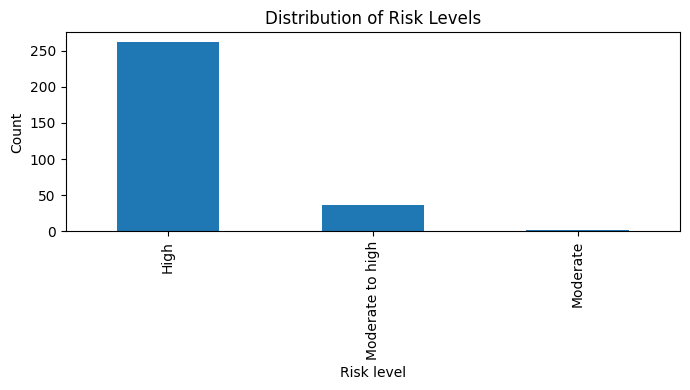

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
df["risk_level"].value_counts().plot(kind="bar")
plt.title("Distribution of Risk Levels")
plt.xlabel("Risk level")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

count    300.000000
mean     125.406667
std        4.558936
min       97.000000
25%      123.000000
50%      126.000000
75%      129.000000
max      137.000000
Name: output_word_count, dtype: float64


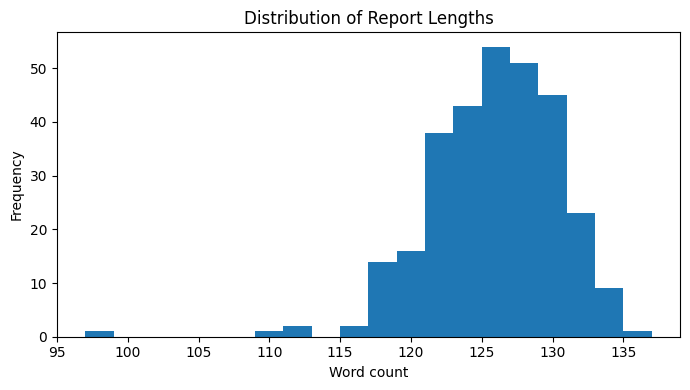

In [ ]:
df["output_word_count"] = df["output"].str.split().str.len()
print(df["output_word_count"].describe())

plt.figure(figsize=(7, 4))
plt.hist(df["output_word_count"], bins=20)
plt.title("Distribution of Report Lengths")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 9) Format dataset for instruction tuning

This helper converts one record into the prompt format used during inference.

In [ ]:
def build_prompt(instruction, input_text):
    return f"""### Instruction:
{instruction}

### Input:
{input_text}

### Response:
"""

example_prompt = build_prompt(train_df.iloc[0]["instruction"], train_df.iloc[0]["input"])
print(example_prompt)

### Instruction:
Generate a transportation safety assessment report for the following intersection conditions.

### Input:
Intersection type: Four-leg unsignalized intersection
Area type: Suburban
Traffic volume: Very high
Speed limit: 80 km/h
Left-turn lane: Present on all major approaches
Right-turn slip lane: None
Pedestrian facilities: Marked crosswalks on all approaches
Bicycle facilities: Bike lane terminates near intersection
Lighting: Adequate
Visibility: Moderate
Roadside condition: Open roadside with limited hazards
Surface condition: Skid resistance concerns reported
Signage and markings: Stop bar visibility poor
Signal operation: Not applicable
Observed conflicts: Near-miss events involving cyclists
Crash history: Frequent angle crashes
Heavy vehicle share: Low

### Response:



## 10) Fine-tuning with Unsloth + LoRA

This section is designed for **Google Colab with GPU**.

### Selected base model
For this project, the best choice among the listed options is:

- **`unsloth/Qwen2.5-3B-Instruct-bnb-4bit`**

### Why this model was selected
It is a strong fit for **intersection safety assessment reporting** because it is:
- lightweight enough for efficient LoRA fine-tuning
- strong at instruction following
- good at producing structured, professional text
- well suited to report-style generation tasks

The cells below are fully uncommented so you can run the workflow directly in Colab.

In [ ]:
import torch
from datasets import Dataset
from unsloth import FastLanguageModel
from trl import SFTTrainer
from transformers import TrainingArguments

BASE_MODEL_NAME = "unsloth/Qwen2.5-3B-Instruct-bnb-4bit"
MAX_SEQ_LENGTH = 1024
LOAD_IN_4BIT = True

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,
    load_in_4bit=LOAD_IN_4BIT,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=SEED,
    use_rslora=False,
    loftq_config=None,
)

def to_text(example):
    text = build_prompt(example["instruction"], example["input"]) + example["output"]
    return {"text": text}

train_ds = Dataset.from_pandas(train_df[["instruction", "input", "output"]], preserve_index=False).map(to_text)
val_ds   = Dataset.from_pandas(val_df[["instruction", "input", "output"]], preserve_index=False).map(to_text)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    dataset_text_field="text",
    max_seq_length=MAX_SEQ_LENGTH,
    dataset_num_proc=2,
    packing=False,
    args=TrainingArguments(
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        warmup_steps=5,
        num_train_epochs=3,
        learning_rate=2e-4,
        fp16=True, # Changed from False to True
        bf16=False, # Changed from True to False
        logging_steps=10,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="linear",
        seed=SEED,
        output_dir=str(MODEL_DIR / "unsloth_outputs"),
        report_to="none",
        eval_strategy="epoch",
        save_strategy="epoch",
    ),
)

trainer_stats = trainer.train()
print(trainer_stats)

# Save LoRA adapters
final_adapter_path = MODEL_DIR / "intersection_safety_lora"
model.save_pretrained(final_adapter_path)
tokenizer.save_pretrained(final_adapter_path)
print("Saved LoRA adapter to:", final_adapter_path)

==((====))==  Unsloth 2026.4.4: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Map:   0%|          | 0/209 [00:00<?, ? examples/s]

Map:   0%|          | 0/45 [00:00<?, ? examples/s]

...

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/45 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 209 | Num Epochs = 3 | Total steps = 81
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss
1,0.899294,0.206696
2,0.115152,0.120358
3,0.093364,0.109162


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

TrainOutput(global_step=81, training_loss=0.5117083973722694, metrics={'train_runtime': 298.6421, 'train_samples_per_second': 2.1, 'train_steps_per_second': 0.271, 'total_flos': 3419095296442368.0, 'train_loss': 0.5117083973722694, 'epoch': 3.0})
Saved LoRA adapter to: project_outputs/models/intersection_safety_lora


## 11) Inference utilities

This section lets you compare:
- the **base model**
- the **fine-tuned model**

You can skip this section until after training is complete.

In [ ]:
import torch
from unsloth import FastLanguageModel

def load_base_model_for_inference(model_name, max_seq_length=1024, load_in_4bit=True):
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=model_name,
        max_seq_length=max_seq_length,
        dtype=None,
        load_in_4bit=load_in_4bit,
    )
    FastLanguageModel.for_inference(model)
    return model, tokenizer

def load_finetuned_model_for_inference(adapter_path, max_seq_length=1024, load_in_4bit=True):
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=str(adapter_path),
        max_seq_length=max_seq_length,
        dtype=None,
        load_in_4bit=load_in_4bit,
    )
    FastLanguageModel.for_inference(model)
    return model, tokenizer

def generate_response(model, tokenizer, instruction, input_text, max_new_tokens=220):
    prompt = build_prompt(instruction, input_text)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        temperature=0.0,
        pad_token_id=tokenizer.eos_token_id,
        use_cache=True,
    )
    text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if "### Response:" in text:
        text = text.split("### Response:", 1)[1].strip()
    return text

base_model, base_tokenizer = load_base_model_for_inference(BASE_MODEL_NAME, MAX_SEQ_LENGTH, LOAD_IN_4BIT)
print("Loaded base model for inference.")

if "final_adapter_path" not in globals():
    final_adapter_path = MODEL_DIR / "intersection_safety_lora"

if Path(final_adapter_path).exists():
    ft_model, ft_tokenizer = load_finetuned_model_for_inference(final_adapter_path, MAX_SEQ_LENGTH, LOAD_IN_4BIT)
    print("Loaded fine-tuned model for inference.")
else:
    ft_model, ft_tokenizer = None, None
    print(f"Fine-tuned adapter not found at: {final_adapter_path}")
    print("Run the fine-tuning cell first, then rerun this cell.")

==((====))==  Unsloth 2026.4.4: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Loaded base model for inference.
==((====))==  Unsloth 2026.4.4: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Loaded fine-tuned model for inference.


## 12) Rule-based baseline evaluation scaffold

If you cannot run the actual LLM in your current machine, use this section first to prepare evaluation tables.  
Later, replace `base_prediction` and `finetuned_prediction` with real generated outputs.

In [ ]:
def extract_keywords(text):
    words = re.findall(r"[a-zA-Z\-]+", text.lower())
    stop = {
        "the","a","an","and","or","of","to","for","with","at","on","in","is","are","be","by",
        "this","that","it","as","from","may","should","under","into","near","than","based"
    }
    return set([w for w in words if len(w) > 3 and w not in stop])

def keyword_overlap_score(reference, prediction):
    ref = extract_keywords(reference)
    pred = extract_keywords(prediction)
    if not ref:
        return 0.0
    return len(ref.intersection(pred)) / len(ref)

def sentence_count(text):
    return max(1, len([s for s in re.split(r"[.!?]+", text) if s.strip()]))

def clarity_score(prediction):
    wc = len(prediction.split())
    sc = sentence_count(prediction)
    avg_len = wc / max(sc, 1)
    # heuristic clarity score out of 5
    score = 5.0
    if wc < 40:
        score -= 1.5
    if avg_len > 35:
        score -= 1.0
    if avg_len < 6:
        score -= 1.0
    return max(1.0, min(5.0, score))

def completeness_score(prediction):
    text = prediction.lower()
    checks = [
        any(x in text for x in ["risk", "safety risk", "moderate", "high", "low"]),
        any(x in text for x in ["concern", "conflict", "crash", "visibility", "pedestrian", "lighting"]),
        any(x in text for x in ["recommend", "countermeasure", "review", "install", "improve", "provide"]),
    ]
    return 1.0 + 4.0 * (sum(checks) / len(checks))

def technical_relevance_score(reference, prediction):
    return 1.0 + 4.0 * keyword_overlap_score(reference, prediction)

def score_prediction(reference, prediction):
    relevance = technical_relevance_score(reference, prediction)
    completeness = completeness_score(prediction)
    clarity = clarity_score(prediction)
    overall = np.mean([relevance, completeness, clarity])
    return {
        "relevance_1to5": round(relevance, 2),
        "completeness_1to5": round(completeness, 2),
        "clarity_1to5": round(clarity, 2),
        "overall_1to5": round(overall, 2),
    }

In [ ]:
sample_eval_rows = []
sample_test_df = test_df.head(10).copy()

for _, row in sample_test_df.iterrows():
    reference = row["output"]
    base_prediction = generate_response(base_model, base_tokenizer, row["instruction"], row["input"])

    if ft_model is not None:
        finetuned_prediction = generate_response(ft_model, ft_tokenizer, row["instruction"], row["input"])
    else:
        finetuned_prediction = "Fine-tuned model not available yet. Run the training cell first."

    base_scores = score_prediction(reference, base_prediction)
    ft_scores = score_prediction(reference, finetuned_prediction)

    sample_eval_rows.append({
        "id": row["id"],
        "base_prediction": base_prediction,
        "ft_prediction": finetuned_prediction,
        "base_overall": base_scores["overall_1to5"],
        "ft_overall": ft_scores["overall_1to5"],
        "base_relevance": base_scores["relevance_1to5"],
        "ft_relevance": ft_scores["relevance_1to5"],
        "base_completeness": base_scores["completeness_1to5"],
        "ft_completeness": ft_scores["completeness_1to5"],
        "base_clarity": base_scores["clarity_1to5"],
        "ft_clarity": ft_scores["clarity_1to5"],
    })

sample_eval_df = pd.DataFrame(sample_eval_rows)
display(sample_eval_df[[
    "id",
    "base_overall", "ft_overall",
    "base_relevance", "ft_relevance",
    "base_completeness", "ft_completeness",
    "base_clarity", "ft_clarity"
]])
print("Average sample scores:")
display(sample_eval_df.mean(numeric_only=True).round(2))

Both `max_new_tokens` (=220) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12

,id,base_overall,ft_overall,base_relevance,ft_relevance,base_completeness,ft_completeness,base_clarity,ft_clarity
0,94,4.09,5.00,2.26,5.00,5.00,5.0,5.0,5.0
1,250,4.11,5.00,2.33,5.00,5.00,5.0,5.0,5.0
2,279,4.01,5.00,2.03,5.00,5.00,5.0,5.0,5.0
3,16,3.69,5.00,2.08,5.00,5.00,5.0,4.0,5.0
4,204,3.94,4.98,1.81,4.95,5.00,5.0,5.0,5.0
5,282,3.21,4.81,1.97,4.44,3.67,5.0,4.0,5.0
6,74,3.25,5.00,2.09,5.00,3.67,5.0,4.0,5.0
7,23,4.06,5.00,2.19,5.00,5.00,5.0,5.0,5.0
8,238,3.60,5.00,2.12,5.00,3.67,5.0,5.0,5.0
9,78,3.33,4.80,2.33,4.41,3.67,5.0,4.0,5.0


Average sample scores:


,0
id,153.80
base_overall,3.73
ft_overall,4.96
base_relevance,2.12
ft_relevance,4.88
base_completeness,4.47
ft_completeness,5.00
base_clarity,4.60
ft_clarity,5.00


## 13) Real evaluation with actual model outputs

After you run inference using the base model and fine-tuned model, save predictions and evaluate them here.

In [ ]:
real_eval_rows = []

for _, row in test_df.iterrows():
    reference = row["output"]
    base_prediction = generate_response(base_model, base_tokenizer, row["instruction"], row["input"])

    if ft_model is not None:
        ft_prediction = generate_response(ft_model, ft_tokenizer, row["instruction"], row["input"])
    else:
        ft_prediction = "Fine-tuned model not available yet. Run the training cell first."

    base_scores = score_prediction(reference, base_prediction)
    ft_scores = score_prediction(reference, ft_prediction)

    real_eval_rows.append({
        "id": row["id"],
        "input": row["input"],
        "reference": reference,
        "base_prediction": base_prediction,
        "ft_prediction": ft_prediction,
        **{f"base_{k}": v for k, v in base_scores.items()},
        **{f"ft_{k}": v for k, v in ft_scores.items()},
    })

real_eval_df = pd.DataFrame(real_eval_rows)
real_eval_path = RESULTS_DIR / "base_vs_finetuned_evaluation.csv"
real_eval_df.to_csv(real_eval_path, index=False)

print("Saved:", real_eval_path)
display(real_eval_df.head(3))

summary_metrics = real_eval_df[[
    "base_relevance_1to5", "ft_relevance_1to5",
    "base_completeness_1to5", "ft_completeness_1to5",
    "base_clarity_1to5", "ft_clarity_1to5",
    "base_overall_1to5", "ft_overall_1to5"
]].mean().round(2)

print("Average evaluation metrics:")
display(summary_metrics.to_frame(name="average_score"))

Both `max_new_tokens` (=220) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=2

Saved: project_outputs/results/base_vs_finetuned_evaluation.csv


,id,input,reference,base_prediction,ft_prediction,base_relevance_1to5,base_completeness_1to5,base_clarity_1to5,base_overall_1to5,ft_relevance_1to5,ft_completeness_1to5,ft_clarity_1to5,ft_overall_1to5
0,94,Intersection type: Roundabout\nArea type: Urba...,This urban roundabout presents a high safety r...,**Transportation Safety Assessment Report**\n\...,This urban roundabout presents a high safety r...,2.26,5.0,5.0,4.09,5.0,5.0,5.0,5.0
1,250,Intersection type: Roundabout\nArea type: Urba...,This urban roundabout presents a high safety r...,**Transportation Safety Assessment Report**\n\...,This urban roundabout presents a high safety r...,2.33,5.0,5.0,4.11,5.0,5.0,5.0,5.0
2,279,Intersection type: Four-leg unsignalized inter...,This suburban four-leg unsignalized intersecti...,## Transportation Safety Assessment Report for...,This suburban four-leg unsignalized intersecti...,2.03,5.0,5.0,4.01,5.0,5.0,5.0,5.0


Average evaluation metrics:


,average_score
base_relevance_1to5,2.17
ft_relevance_1to5,4.90
base_completeness_1to5,4.31
ft_completeness_1to5,5.00
base_clarity_1to5,4.52
ft_clarity_1to5,5.00
base_overall_1to5,3.66
ft_overall_1to5,4.97


## 14) Create a few side-by-side qualitative examples for the report

In [ ]:
qual_examples = []

source_df = real_eval_df.head(3) if "real_eval_df" in globals() else pd.DataFrame()

if len(source_df) == 0:
    raise ValueError("Run the real evaluation cell first so qualitative examples can be created.")

for _, row in source_df.iterrows():
    qual_examples.append({
        "Input": row["input"],
        "Reference": row["reference"],
        "Base model output": row["base_prediction"],
        "Fine-tuned model output": row["ft_prediction"]
    })

qual_df = pd.DataFrame(qual_examples)
qual_path = RESULTS_DIR / "qualitative_examples.csv"
qual_df.to_csv(qual_path, index=False)
print("Saved:", qual_path)
display(qual_df)

Saved: project_outputs/results/qualitative_examples.csv


,Input,Reference,Base model output,Fine-tuned model output
0,Intersection type: Roundabout\nArea type: Urba...,This urban roundabout presents a high safety r...,**Transportation Safety Assessment Report**\n\...,This urban roundabout presents a high safety r...
1,Intersection type: Roundabout\nArea type: Urba...,This urban roundabout presents a high safety r...,**Transportation Safety Assessment Report**\n\...,This urban roundabout presents a high safety r...
2,Intersection type: Four-leg unsignalized inter...,This suburban four-leg unsignalized intersecti...,## Transportation Safety Assessment Report for...,This suburban four-leg unsignalized intersecti...


## 15) Export a small methodology summary automatically

This generates text you can reuse in your report.

In [ ]:
methodology_summary = f'''
This study developed a synthetic instruction-based dataset for intersection safety assessment reporting.
A total of {NUM_SAMPLES} samples were generated programmatically using transportation-related variables including
intersection type, traffic volume, speed limit, pedestrian facilities, bicycle facilities, lighting, visibility,
roadside condition, signage, signal operation, observed conflicts, and crash history. Each sample contained an
instruction, structured input description, and expert-style target report. The dataset was split into training,
validation, and testing subsets using ratios of {TRAIN_RATIO:.0%}, {VAL_RATIO:.0%}, and {TEST_RATIO:.0%}, respectively.
A lightweight instruction-tuned large language model can then be fine-tuned using LoRA within the Unsloth framework.
Model performance is evaluated by comparing the base and fine-tuned models on the test set using rubric-based
criteria including relevance, completeness, and clarity, supported by qualitative output comparison.
'''.strip()

summary_path = RESULTS_DIR / "methodology_summary.txt"
with open(summary_path, "w", encoding="utf-8") as f:
    f.write(methodology_summary)

print(methodology_summary)
print("\nSaved:", summary_path)

This study developed a synthetic instruction-based dataset for intersection safety assessment reporting.
A total of 300 samples were generated programmatically using transportation-related variables including
intersection type, traffic volume, speed limit, pedestrian facilities, bicycle facilities, lighting, visibility,
roadside condition, signage, signal operation, observed conflicts, and crash history. Each sample contained an
instruction, structured input description, and expert-style target report. The dataset was split into training,
validation, and testing subsets using ratios of 70%, 15%, and 15%, respectively.
A lightweight instruction-tuned large language model can then be fine-tuned using LoRA within the Unsloth framework.
Model performance is evaluated by comparing the base and fine-tuned models on the test set using rubric-based
criteria including relevance, completeness, and clarity, supported by qualitative output comparison.

Saved: project_outputs/results/methodology_su

## 17) Download all outputs

In [ ]:
import zipfile
import os
from google.colab import files

output_zip_name = f"{PROJECT_NAME}_outputs.zip"

with zipfile.ZipFile(output_zip_name, 'w') as zipf:
    for root, dirs, file_list in os.walk(OUTPUT_DIR):
        for file in file_list:
            file_path = os.path.join(root, file)
            # Archive path should be relative to the OUTPUT_DIR
            archive_path = os.path.relpath(file_path, OUTPUT_DIR)
            zipf.write(file_path, os.path.join(OUTPUT_DIR.name, archive_path))

print(f"Successfully created {output_zip_name} containing all project outputs.")

# Provide a download link
files.download(output_zip_name)

Successfully created intersection_safety_llm_outputs.zip containing all project outputs.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 16) Final notes

### What this notebook already does
- generates a realistic **synthetic dataset**
- saves it in **training-ready formats**
- uses **`unsloth/Qwen2.5-3B-Instruct-bnb-4bit`** as the selected base model
- provides **Unsloth + LoRA** fine-tuning code
- provides **base vs fine-tuned evaluation**
- exports qualitative examples for your final report

### Recommended execution order
Run the notebook from top to bottom:
1. install packages  
2. generate dataset  
3. split data  
4. fine-tune the model  
5. load base and fine-tuned models  
6. run evaluation  
7. export tables and examples for the PDF report